# KPIs

##### KPI 1- Tasa de ocupacion
##### KPI 2- Ciudad con mayor ocupacion
##### KPI 3- Indice de satisfacion genereal
##### KPI 4- Item con mayor satisfacion promedio

In [1]:
# Imporatacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Importacion de los datos

df = pd.read_csv("../Data/cleaned_tourist_accommodation_04_05.csv")
# df = pd.read_csv("cleaned_tourist_accommodation_20_04.csv")


## KPI 1- Tasa de ocupacion mensual

In [3]:
# Formula: (numero dias ocupados / numero dias disponibles) * 100

# availability_30 = días disponibles en los próximos 30 días
# días ocupados   = 30 - availability_30

In [4]:
def calcular_kpi1(df):
    df = df.copy()
    df['occupied_days_30'] = 30 - df['availability_30']
    df['occupancy_rate']   = (df['occupied_days_30'] / 30) * 100
    kpi1 = df['occupancy_rate'].mean()
    return kpi1

In [5]:
def grafico_kpi1(kpi1):
    fig, ax = plt.subplots(figsize=(7, 2))
    ax.barh(['Ocupación'], [kpi1],       color='steelblue', label=f'Ocupado: {kpi1:.1f}%')
    ax.barh(['Ocupación'], [100 - kpi1], left=[kpi1], color='lightgrey', label='Disponible')
    ax.set_xlim(0, 100)
    ax.set_xlabel('%')
    ax.set_title(f'KPI 1 — Tasa de ocupación mensual: {kpi1:.1f}%')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

## KPI 2- Ciudad con mayor ocupacion

In [6]:
def calcular_kpi2(df):
    city_occ = (
        df.groupby('city')
        .apply(lambda g: (30 - g['availability_30']).sum() / (30 * len(g)) * 100)
        .reset_index()
    )
    city_occ.columns = ['city', 'occupancy_rate_pct']
    city_occ = city_occ.sort_values('occupancy_rate_pct', ascending=False)
    kpi2 = city_occ.iloc[0]
    return kpi2, city_occ

In [7]:
def grafico_kpi2(kpi2, city_occ):
    colors = ['tomato' if c == kpi2['city'] else 'steelblue' for c in city_occ['city']]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(city_occ['city'], city_occ['occupancy_rate_pct'], color=colors)
    ax.set_ylabel('Tasa de ocupación (%)')
    ax.set_title(f"KPI 2 — Ciudad con mayor ocupación: {kpi2['city']} ({kpi2['occupancy_rate_pct']:.1f}%)")
    ax.set_ylim(0, 100)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## KPI 3- Indice de satisfacion genereal

In [8]:
# SUM(rreview_scores_rating_clean) / Numero alojamientos

In [9]:
def calcular_kpi3(df):
    df_rated = df.dropna(subset=['review_scores_rating_clean'])
    kpi3 = df_rated['review_scores_rating_clean'].sum() / len(df_rated)
    return kpi3, df_rated

In [10]:
def grafico_kpi3(kpi3, df_rated):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(df_rated['review_scores_rating_clean'], bins=30, color='steelblue', ax=ax)
    ax.axvline(kpi3, color='tomato', linewidth=2, linestyle='--', label=f'Media: {kpi3:.2f}')
    ax.set_xlabel('review_scores_rating_clean')
    ax.set_title('KPI 3 — Distribución del índice de satisfacción general')
    ax.legend()
    plt.tight_layout()
    plt.show()

## KPI 4- Item con mayor satisfacion promedio

In [11]:
def calcular_kpi4(df):
    score_cols = {
        'accuracy':      'review_scores_accuracy',
        'cleanliness':   'review_scores_cleanliness',
        'checkin':       'review_scores_checkin',
        'communication': 'review_scores_communication',
        'location':      'review_scores_location'
    }
    avg_scores        = {label: df[col].mean() for label, col in score_cols.items()}
    avg_scores_series = pd.Series(avg_scores).sort_values(ascending=False)
    kpi4_item         = avg_scores_series.idxmax()
    kpi4_value        = avg_scores_series.max()
    return kpi4_item, kpi4_value, avg_scores_series

In [12]:
def grafico_kpi4(kpi4_item, kpi4_value, avg_scores_series):
    avg_df         = avg_scores_series.reset_index()
    avg_df.columns = ['item', 'score']
    colors         = ['tomato' if i == kpi4_item else 'steelblue' for i in avg_df['item']]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(avg_df['item'], avg_df['score'], color=colors)
    ax.set_xlabel('Puntuación promedio')
    ax.set_title(f'KPI 4 — Ítem con mayor satisfacción: {kpi4_item} ({kpi4_value:.2f})')
    ax.set_xlim(avg_df['score'].min() - 0.2, avg_df['score'].max() + 0.2)
    plt.tight_layout()
    plt.show()

#### Ejecucion

KPI 1 — Tasa de ocupación mensual: 56.50%


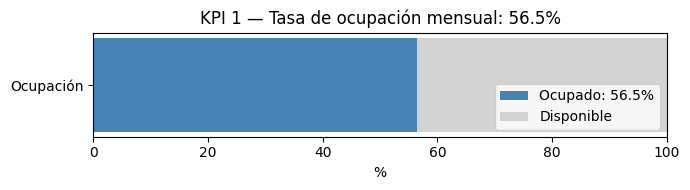

In [13]:
# KPI 1
kpi1 = calcular_kpi1(df)
print(f"KPI 1 — Tasa de ocupación mensual: {kpi1:.2f}%")
grafico_kpi1(kpi1)


KPI 2 — Ciudad con mayor ocupación: madrid (60.91%)
     city  occupancy_rate_pct
   madrid           60.905967
barcelona           60.020841
   malaga           57.281746
 valencia           55.263158
 mallorca           53.198568
  menorca           52.293578
   girona           50.273850
  sevilla           49.817814


C:\Users\pnnes\AppData\Local\Temp\ipykernel_22556\4051455142.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (30 - g['availability_30']).sum() / (30 * len(g)) * 100)


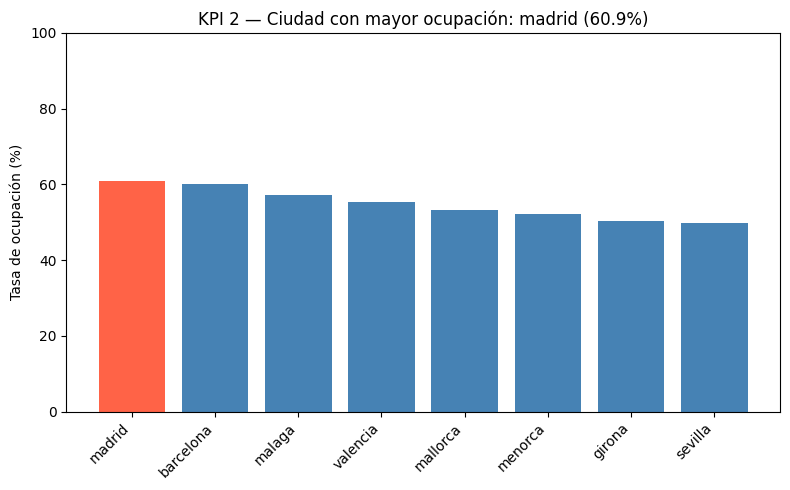

In [14]:
# KPI 2
kpi2, city_occ = calcular_kpi2(df)
print(f"\nKPI 2 — Ciudad con mayor ocupación: {kpi2['city']} ({kpi2['occupancy_rate_pct']:.2f}%)")
print(city_occ.to_string(index=False))
grafico_kpi2(kpi2, city_occ)


KPI 3 — Índice de satisfacción general: 91.90
  (sobre 7025 alojamientos con puntuación)


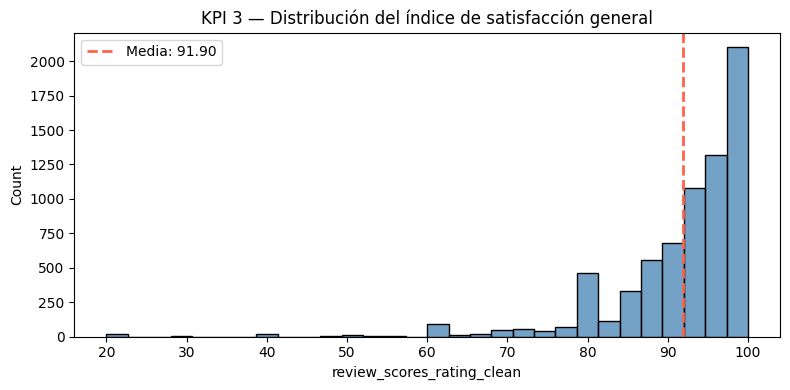

In [15]:
# KPI 3
kpi3, df_rated = calcular_kpi3(df)
print(f"\nKPI 3 — Índice de satisfacción general: {kpi3:.2f}")
print(f"  (sobre {len(df_rated)} alojamientos con puntuación)")
grafico_kpi3(kpi3, df_rated)


KPI 4 — Ítem con mayor satisfacción: checkin (96.2202)


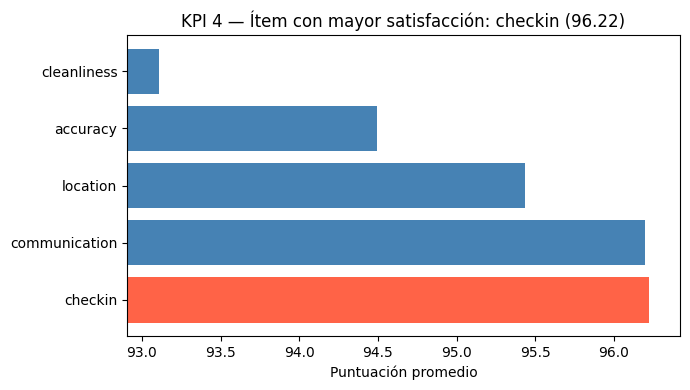

In [16]:
# KPI 4
kpi4_item, kpi4_value, avg_scores_series = calcular_kpi4(df)
print(f"\nKPI 4 — Ítem con mayor satisfacción: {kpi4_item} ({kpi4_value:.4f})")
grafico_kpi4(kpi4_item, kpi4_value, avg_scores_series)